# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 3: RNN и языковые модели 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 12.75, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 7.83 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 15 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в архиве `jokes.txt.zip`, который доступен по [ссылке](https://disk.yandex.com/d/fjt5xICH-ukEEA).

In [1]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (1 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [3]:
!pip install sentencepiece


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import torch
import numpy as np
from dataset import TextDataset

In [7]:
train_set = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe')
valid_set = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe')

In [6]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length, )
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1:] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (3.5 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [8]:
from model import LanguageModel

In [9]:
model = LanguageModel(train_set)

In [9]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs, ))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ['', 'купил мужик шляпу,', 'сел медведь в машину и', 'подумал штирлиц']:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (2 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://towardsdatascience.com/perplexity-in-language-models-87a196019a94). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_set, batch_size=32, shuffle=False)

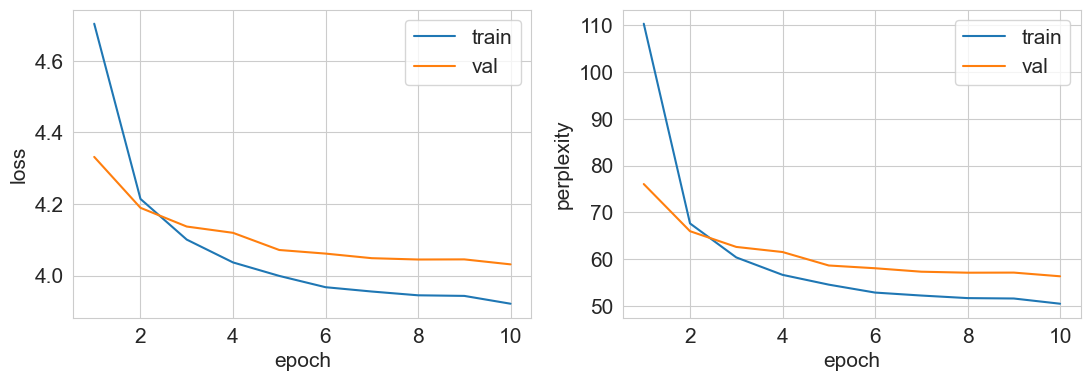

Generation examples:
- алло, накацию говорит?- нет, же бы я тебе могу узнать, подняться.
чертов неожима укориса какую- я не умею процветать.
и случилось вторника подъехал пришли шутить палку- ну, чего пожить насели?- ты оказывается, крутить! подумал штирлиц орет и нет, аплодировала со звезда.
не в мире нервным ценам в твоинии можно претенте?- поклонский трудную на той и сделать еще как цыгане, тяжело это!- ну вот ты была забозное к ситуацию ты.
собачная позор и сердце- пиво прямо много времени, возьми в заложном?- тогда кончается...


In [13]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from torch import nn
from train import train

model = LanguageModel(train_set).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train(model, optimizer, scheduler=None, 
      train_loader=train_loader, val_loader=val_loader, 
      num_epochs=10)
      
torch.save(model.state_dict(), 'rnn_checkpoint.pth')

## Задание 4: LSTM (0.5 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

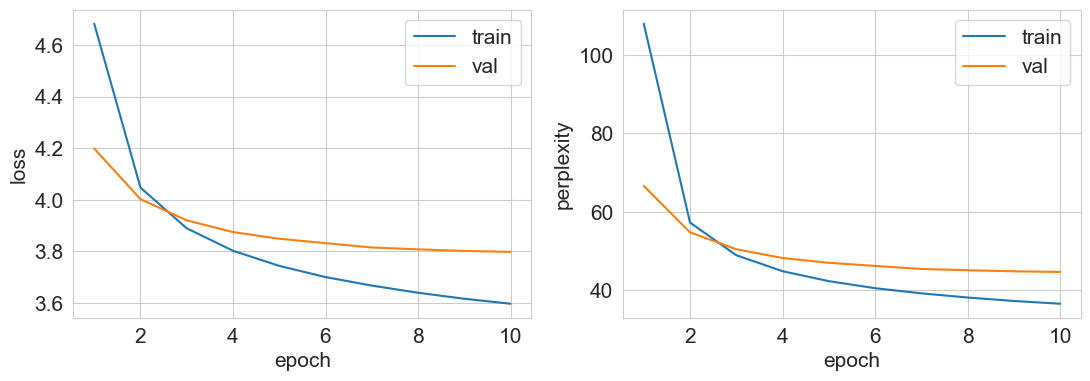

Generation examples:
- у вас такой резиновый ты окончательно разобчитал стригу, дураки, боярышника.- нет.непроспала 1 и говорит- пап, а какие лягушка рыбы? пять тысяч идиоти  ⁇ 0 лет!
- ты уверена, что он все деревянный говном в туалете был так, сдаю свою девушку.- а я, как равится, ты просто зазвонил телефон?- а я рыба от меня за собой стреляет.
два человека есть реально-литом и умной и третьего лето, которое доставили периоды для пяти.- какие?- у меня в другом кухарке я не оглядывая девочке - не есть!
рекламное оружие действия запасы на 20 лет сша про золушке еще смерт с гордно с каждым поятилом.
- да, но еврея.высочет предсе.- ну, потому дать только направляю посуду мертвой домашний!


In [14]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model = LanguageModel(train_set, rnn_type=nn.LSTM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train(model, optimizer, scheduler=None, 
      train_loader=train_loader, val_loader=val_loader, 
      num_epochs=10)
      
torch.save(model.state_dict(), 'lstm_checkpoint.pth')


Perplexity у LSTM явно ниже, на тесте (~43) против ванильной RNN (~58). По лоссам у LSTM снова ниже (3.8 vs 4.2). По генерации текста LSTM делает это лучше. 

## Задание 5: Sampling temperature (0.5 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [12]:

from torch import nn
from train import train
from model import LanguageModel
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [13]:
rnn_model =  LanguageModel(train_set, rnn_type=nn.RNN).to(device)
rnn_model.load_state_dict(torch.load('rnn_checkpoint.pth'))

lstm_model =  LanguageModel(train_set, rnn_type=nn.LSTM).to(device)
lstm_model.load_state_dict(torch.load('lstm_checkpoint.pth'))

<All keys matched successfully>

In [15]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
prefs = ["бабуин","встречаются", "трамп приходит", "сам рушуууу сам решууу", "вованчик адидас влетает спыру"]
temps = np.linspace(0.1,2,10)

for pref in prefs:
    for temp in temps:
        rnn_gen = rnn_model.inference(pref, temp)
        lstm_gen = lstm_model.inference(pref, temp)

        print('prefs: ', pref)
        print('temp: ', temp)
        print('rnn',rnn_gen )
        print('lstm:', lstm_gen)
        print()



prefs:  бабуин
temp:  0.1
rnn бабуин- а ты, наверное, у меня есть?- нет, я не могу, я не могу, а ты не хочешь, если бы не поверил, а потом уже не знал, что он не умеет.
lstm: бабуин, что ты не знаешь, что у меня есть парень, который может быть, когда ты нашел себе на работу, а ты что, не знаешь, что ты не знаешь, что ты не знаешь, что ты будешь делать?

prefs:  бабуин
temp:  0.3111111111111111
rnn бабуин- а что такое?- да, но ты же не знаем, а ты меня не видел, как ты думаешь, у нас в школе, когда в россии не могут найти себя в россии.
lstm: бабуин, что это такое, что я с тобой, в принципе, это не значит, что он не поцеловал, а не на что-то некрасиво.

prefs:  бабуин
temp:  0.5222222222222223
rnn бабуин - это когда ты зарабатываешь вверх, то, что он не знал, что нечета.
lstm: бабуин клювом отделениях и начнет использовать в европу, а ремни ссориться.

prefs:  бабуин
temp:  0.7333333333333333
rnn бабуин- прикалываете?- я имел у меня в голове?
lstm: бабуин, а мужика вздохнув с отцом в ит

При маленькой температуре ($T \to 0$) распределение вероятностей становится острым: модель почти всегда выбирает самый вероятный токен -argmax. Генерация получается очень связной, грамматически верной, но скучной и предсказуемой (часто зацикливается).

При высокой температуре ($T \to \infty$) распределение становится плоским-равномерным: разница между вероятными и невероятными словами стирается. Модель начинает выбирать редкие и случайные токены. Генерация становится "креативной", но часто теряет смысл и превращается в бред

## Задание 5: Tokenizers (1 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [14]:
train_set_new = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='bpe5', vocab_size=5000, model_type='bpe')
valid_set_new = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='bpe5', vocab_size=5000, model_type='bpe')


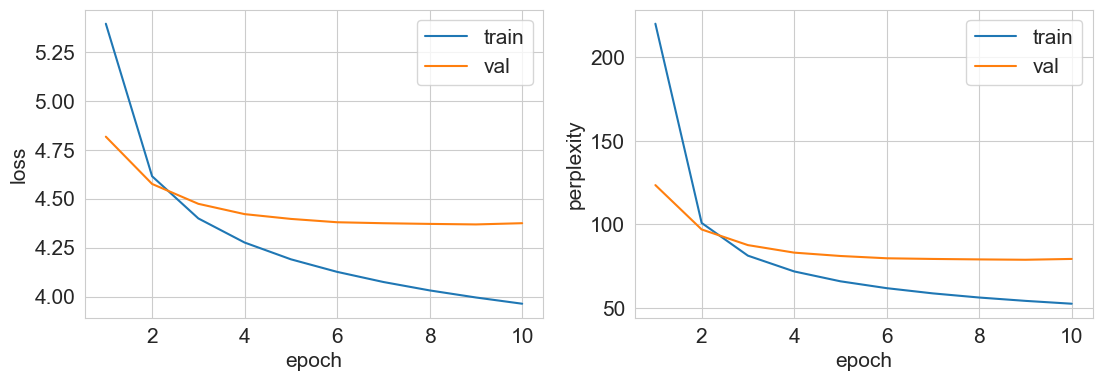

Generation examples:
что такое чувство, что средства россии - это женщин ревсказуются.
прочитал у нас на кухне компьютерные ночной балу ленин и они лысые назвали бесплатные вопросы, вроде как и как проопецровали изводщую штуки для полки восьми знания украины?несмертной не ошибки по магазинам и с ропотацией!?
хочешь гладить, если сука моему сыну.
- что, в ваш любимый фильм красоты?- хорошие деньги они нам бы необходимостью горничь правительство замениться!- а больно?- пошла мой парень.
в ответ на заметку, чтобы стать людей в операцию. но оказалось как минимум для глаз на пол.- а что сказал? вот это он недомунута!- хорошо, давно мешает-дус мне виски.- а у них скоро будет бандеры! выговорили мне вход насре!


In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model_5k= LanguageModel(train_set_new, rnn_type=nn.LSTM).to(device)
optimizer = torch.optim.Adam(model_5k.parameters(), lr=1e-3)

train(model_5k, optimizer, scheduler=None, 
      train_loader=train_loader_new, val_loader=val_loader_new, 
      num_epochs=10)
      
torch.save(model_5k.state_dict(), 'lstm_5k_checkpoint.pth')


In [15]:
from torch.utils.data import DataLoader
train_set_new = TextDataset(data_file='jokes.txt', train=True, sp_model_prefix='unigram5k', vocab_size=5000, model_type='unigram')
valid_set_new = TextDataset(data_file='jokes.txt', train=False, sp_model_prefix='unigram5k', vocab_size=5000, model_type='unigram')


train_loader_new = DataLoader(train_set_new, batch_size=32, shuffle=True)
val_loader_new = DataLoader(valid_set_new, batch_size=32, shuffle=False)

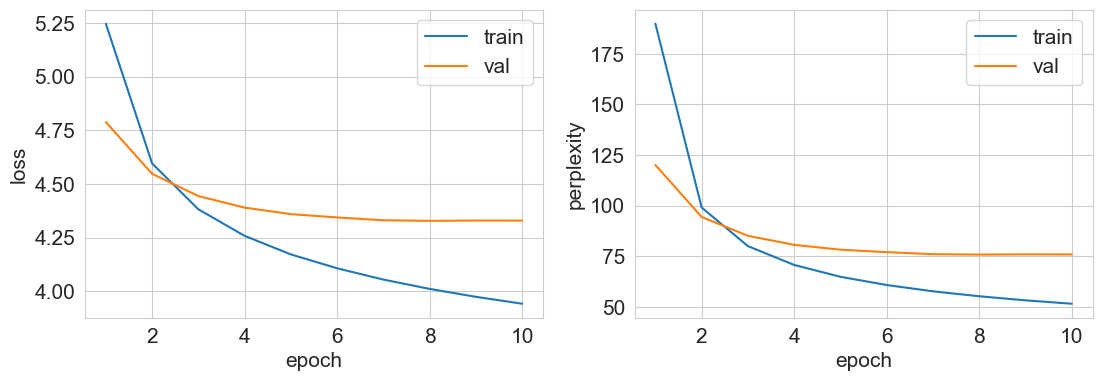

Generation examples:
уж прекрасная играем надо иметь в активной чувствным видом и согласно мертвым.
дртушов выавелиенный, на котором руководства.
две подруги- слушаю себе себе сибирских сил!- ну...- или хорошо, уже спрашивал беримена прыщи...
- ты бы делала?- слышу, водка не настой... потому что я готов пожусь с порочнымикой. здоровье полон не спать!- а байден...
штирлиц шел злую телевизору-был по-будто. блогер - усы!


In [29]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model_5k_unigram= LanguageModel(train_set_new, rnn_type=nn.LSTM).to(device)
optimizer = torch.optim.Adam(model_5k_unigram.parameters(), lr=1e-3)

train(model_5k_unigram, optimizer, scheduler=None, 
      train_loader=train_loader_new, val_loader=val_loader_new, 
      num_epochs=10)
      
torch.save(model_5k_unigram.state_dict(), 'lstm_5k_unigram_checkpoint.pth')


Результаты примерно одинаковые. Ошибки тоже примерно одинаковые. По perplexity сравнивать нельзя, тк зависит от размера словаря. Он зависит от типа токенизации

## Задание 6. Latent Semantic Analysis (2 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [19]:
dataset_bpe = TextDataset('jokes.txt', train=False, sp_model_prefix='bpe', vocab_size=2000, model_type='bpe')

In [20]:
lstm_model = LanguageModel(dataset_bpe, rnn_type=nn.LSTM).to(device)
lstm_model.load_state_dict(torch.load('lstm_checkpoint.pth'))

<All keys matched successfully>

In [28]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm.notebook import tqdm

def LSA(model: LanguageModel, dataset: TextDataset, n_samples: int = None):
    if n_samples is None:
        n_samples = len(dataset)
    
    val_texts = []
    for i in tqdm(range(min(n_samples, len(dataset)))):
        
        indices, _ = dataset[i]
        text = dataset.ids2text(indices)
        val_texts.append(text)

    gen_texts = []
    print(f"Generating {len(val_texts)} texts")
    for _ in tqdm(range(len(val_texts))):
        gen_texts.append(model.inference(temp=0.8))

    
    all_texts = val_texts + gen_texts
    n = len(val_texts)

    vectorizer = TfidfVectorizer(max_features=10000) 
    tfidf_matrix = vectorizer.fit_transform(all_texts)

    svd = TruncatedSVD(n_components=100, random_state=42)
    lsa_matrix = svd.fit_transform(tfidf_matrix) 
    
    vectors_val = lsa_matrix[:n]      # (n, 100)
    vectors_gen = lsa_matrix[n:]      # (n, 100)
    sim_matrix = cosine_similarity(vectors_gen, vectors_val) # (n_gen, n_val)
    max_sims = np.max(sim_matrix, axis=1) # (n_gen,) -> макс схожесть для каждого ген. текста
    score = np.mean(max_sims)

    return score, vectors_val, vectors_gen

In [30]:
dataset_bpe = TextDataset('jokes.txt', train=False, sp_model_prefix='bpe', vocab_size=2000, model_type='bpe')
score_bpe, _, _ = LSA(lstm_model, dataset_bpe) 
print(f"BPE (2k) LSA Score: {score_bpe:.4f}\n")

# BPE (5000)
dataset_bpe5k = TextDataset('jokes.txt', train=False, sp_model_prefix='bpe5', vocab_size=5000, model_type='bpe')
lstm_bpe5k = LanguageModel(dataset_bpe5k, rnn_type=nn.LSTM).to(device)
lstm_bpe5k.load_state_dict(torch.load('lstm_5k_checkpoint.pth'))
score_bpe5k, _, _ = LSA(lstm_bpe5k, dataset_bpe5k)
print(f"BPE (5k) LSA Score: {score_bpe5k:.4f}\n")

# Unigram (5000)
dataset_uni = TextDataset('jokes.txt', train=False, sp_model_prefix='unigram5k', vocab_size=5000, model_type='unigram')
lstm_uni = LanguageModel(dataset_uni, rnn_type=nn.LSTM).to(device)
lstm_uni.load_state_dict(torch.load('lstm_5k_unigram_checkpoint.pth'))
score_uni, _, _ = LSA(lstm_uni, dataset_uni)
print(f"Unigram (5k) LSA Score: {score_uni:.4f}\n")

  0%|          | 0/6038 [00:00<?, ?it/s]

Generating 6038 texts


  0%|          | 0/6038 [00:00<?, ?it/s]

BPE (2k) LSA Score: 0.7120



  0%|          | 0/6038 [00:00<?, ?it/s]

...

BPE (5k) LSA Score: 0.7129



  0%|          | 0/6038 [00:00<?, ?it/s]

Generating 6038 texts


  0%|          | 0/6038 [00:00<?, ?it/s]

Unigram (5k) LSA Score: 0.7161



Плюсы:
1. Меньше шума в данных
2. Можем убирать слова которые не влияют на контекст но часто попадаются
3. Можно сравнивать похожесть текстов

Минусы:

1. Метрика не учитывает разнообразность генерируемых текстов, поэтому если модель будет выдавать одно и то же, но похожее на текст из валидации, то она получит высокий скор.
2. Чтобы посчитать метрику нужно произвести достаточно много вычислений (во время инференса, вычисления SVD).
3. Для SVD нужно заранее понимать какой ранг будет оптимальным, то есть примерно понимать количество важных тем в текстах.

## Задание 7. Visualization (1 балл)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

  0%|          | 0/6038 [00:00<?, ?it/s]

Generating 6038 texts


  0%|          | 0/6038 [00:00<?, ?it/s]

BPE_2k LSA Score 0.7130


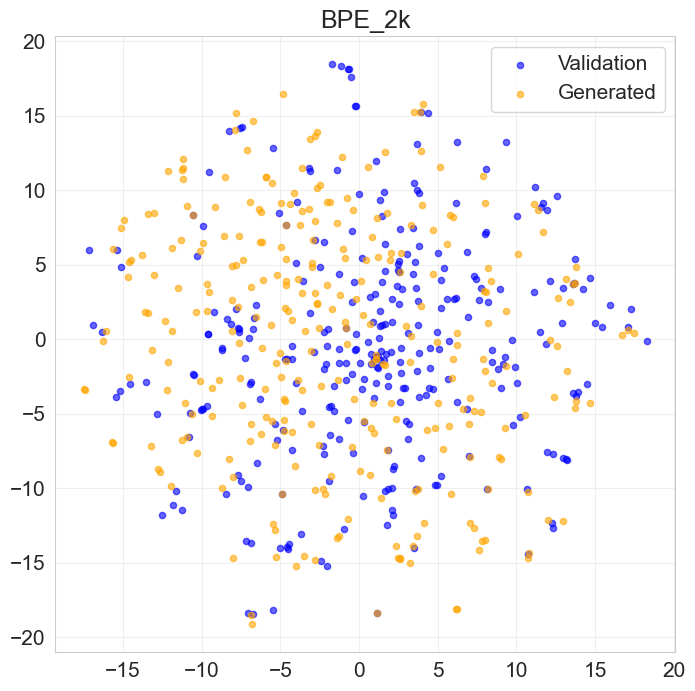

  0%|          | 0/6038 [00:00<?, ?it/s]

Generating 6038 texts


  0%|          | 0/6038 [00:00<?, ?it/s]

BPE_5k LSA Score 0.7134


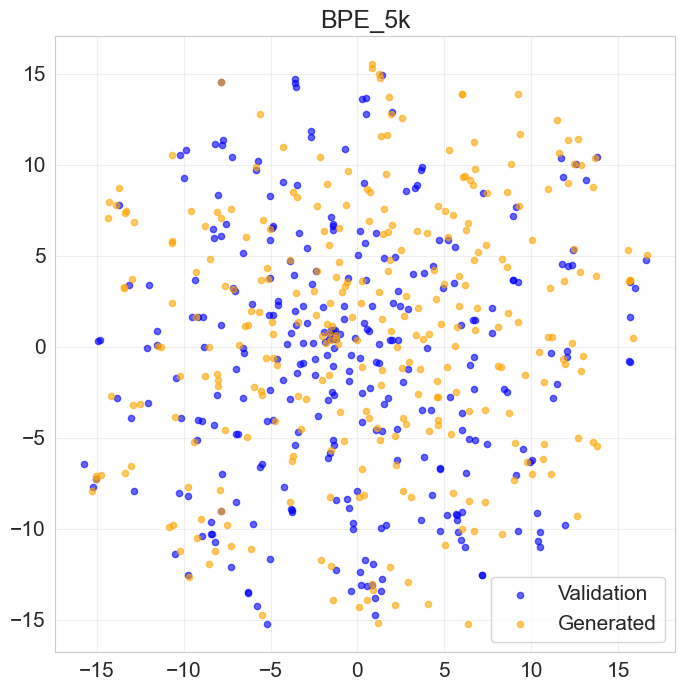

  0%|          | 0/6038 [00:00<?, ?it/s]

Generating 6038 texts


  0%|          | 0/6038 [00:00<?, ?it/s]

Unigram_5k LSA Score 0.7196


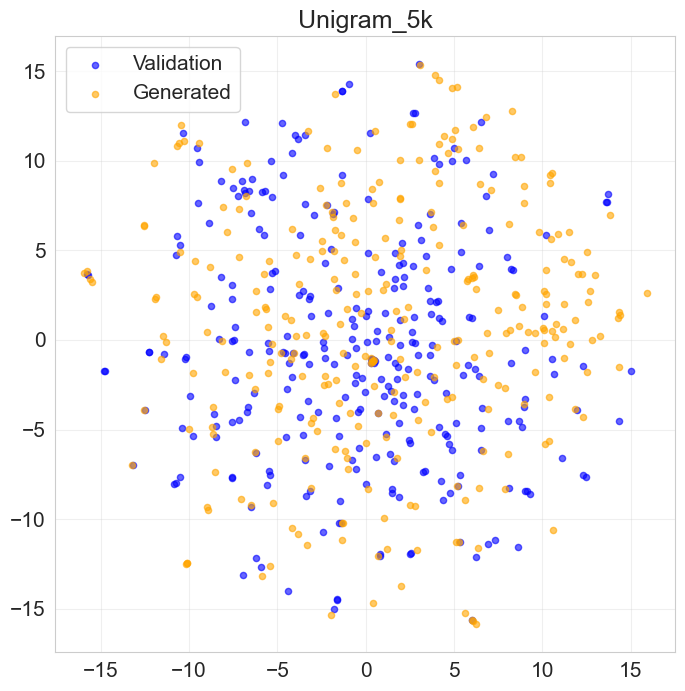

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

def visualize_tsne(model, dataset, title):
    score, vectors_val, vectors_gen = LSA(model, dataset)
    print(f"{title} LSA Score {score:.4f}")

    n_plot = min(300, len(vectors_val))
    idx_val = np.random.choice(len(vectors_val), n_plot, replace=False)
    idx_gen = np.random.choice(len(vectors_gen), n_plot, replace=False)
    
    vec_val_sample = vectors_val[idx_val]
    vec_gen_sample = vectors_gen[idx_gen]

    all_vecs = np.vstack([vec_val_sample, vec_gen_sample])
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='random', learning_rate='auto')
    points = tsne.fit_transform(all_vecs)

    plt.figure(figsize=(8, 8))
    plt.scatter(points[:n_plot, 0], points[:n_plot, 1], alpha=0.6, label='Validation', s=20, c='blue')
    plt.scatter(points[n_plot:, 0], points[n_plot:, 1], alpha=0.6, label='Generated', s=20, c='orange')
    
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# BPE (2000)
visualize_tsne(lstm_model, dataset_bpe, "BPE_2k")

# BPE (5000)
visualize_tsne(lstm_bpe5k, dataset_bpe5k, "BPE_5k")

# Unigram (5000)
visualize_tsne(lstm_uni, dataset_uni, "Unigram_5k")

## Задание 8. ruGPT perplexity (3.5 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [33]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
!pip install transformers

from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "ai-forever/rugpt3small_based_on_gpt2"
gpt_tokenizer = AutoTokenizer.from_pretrained(model_id)
gpt_model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
gpt_model.eval()

def ppl(our_model, checker_model, checker_tokenizer, n_texts=200):
    texts = [our_model.inference() for _ in tqdm(range(n_texts))]

    encodings = checker_tokenizer("\n\n".join(texts), return_tensors="pt")

    max_length = checker_model.config.n_positions
    stride = 512
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = 0
    for begin_loc in range(0, seq_len, stride):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100

        with torch.no_grad():
            outputs = checker_model(input_ids, labels=target_ids)
            neg_log_likelihood = outputs.loss * trg_len

        nlls.append(neg_log_likelihood)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    return torch.exp(torch.stack(nlls).sum() / end_loc)

# Запуск
ppl_bpe = ppl(lstm_model, gpt_model, gpt_tokenizer)
print(f"BPE (2k) PPL: {ppl_bpe:.2f}")

ppl_bpe5k = ppl(lstm_bpe5k, gpt_model, gpt_tokenizer)
print(f"BPE (5k) PPL: {ppl_bpe5k:.2f}")

ppl_uni = ppl(lstm_uni, gpt_model, gpt_tokenizer)
print(f"Unigram (5k) PPL: {ppl_uni:.2f}")

  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 5.4 MB/s eta 0:00:00 0:00:01
Using cached huggingface_hub-1.4.1-py3-none-any.whl (553 kB)
Using cached hf_xet-1.2.0-cp37-abi3-macosx_11_0_arm64.whl (2.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 6.9 MB/s eta 0:00:00a 0:00:01
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Us

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

BPE (2k) PPL: 489.37


  0%|          | 0/200 [00:00<?, ?it/s]

BPE (5k) PPL: 448.84


  0%|          | 0/200 [00:00<?, ?it/s]

Unigram (5k) PPL: 392.95


Получилось что у самой модели с unigram 5k perplexity ниже

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.